Pareto

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ==============================================================================
# 1. PUBLICATION STYLE SETTINGS
# ==============================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman", "serif"],
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.grid": False,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})


# ---------------------------------------------------------
# 2. Pareto front: minimise negative LL and NumParams 
# ---------------------------------------------------------
def build_pareto_front(df, ll_col="negLLout", k_col="numParams"):
    if df.empty:
        return pd.DataFrame()
    # Sort first by params, then by LL
    df_sorted = df.sort_values(by=[k_col, ll_col], ascending=[True, True])
    pareto_front = []
    min_ll_seen = np.inf
    
    for _, row in df_sorted.iterrows():
        if row[ll_col] < min_ll_seen:
            pareto_front.append(row)
            min_ll_seen = row[ll_col]
            
    return pd.DataFrame(pareto_front)

# ---------------------------------------------------------
# 3. Plotting function
# ---------------------------------------------------------

def pareto_plot(df, df_pareto, idx_aic, idx_ll, seed):

    fig, ax = plt.subplots(figsize=(9, 6))

    # vertical lines per parameter count
    for k in sorted(df['numParams'].unique()):
        ax.axvline(k, color='0.9', lw=0.5, zorder=0)

    # candidates
    ax.scatter(df['numParams'], df['negLLout'], s=10, c='0.5', marker='.', label='Candidates', zorder=1)

    # Pareto front
    ax.scatter(df_pareto['numParams'], df_pareto['negLLout'], s=70, c='k', marker='*', label='Pareto front', zorder=3)

    # Identify the AIC-optimal model    
    ax.scatter(df.loc[idx_ll]['numParams'], df.loc[idx_ll]['negLLout'],s=150, facecolors='white', edgecolors='tab:blue', linewidths=2.5, marker='o', label='Best LL', zorder=4)
    ax.scatter(df.loc[idx_aic]['numParams'], df.loc[idx_aic]['negLLout'],s=150, facecolors='white', edgecolors='tab:green', linewidths=2.5, marker='o', label='Best AIC', zorder=4)

    ax.set_xlabel('Number of parameters')
    ax.set_ylabel('Negative Loglikelihood')
    ax.legend(frameon=False, loc='upper right')
    #ax.set_ylim(top=1)
    plt.tight_layout()
    print(f"{seed}")
    plt.savefig(f'Pareto_Front_{seed}.pdf', format='pdf', bbox_inches='tight')   

    plt.tight_layout()
    plt.show()

def pareto_plot_zoom(df, df_pareto, idx_aic, idx_ll, _seed):
    if df.empty or df_pareto.empty:
        return
        
    fig, ax = plt.subplots(figsize=(9, 6))
    for k in sorted(df['numParams'].unique()):
        ax.axvline(k, color='0.9', lw=0.5, zorder=0)
    # candidates
    ax.scatter(df['numParams'], df['negLLout'], s=10, c='0.5', marker='.', label='Candidates', zorder=1)
    
    # Pareto front
    ax.scatter(df_pareto['numParams'], df_pareto['negLLout'], s=70, c='k', marker='*', label='Pareto front', zorder=3)
    ax.plot(df_pareto['numParams'], df_pareto['negLLout'], c='k', linestyle='-', zorder=2)
    ax.scatter(df.loc[idx_ll]['numParams'], df.loc[idx_ll]['negLLout'],s=80, facecolors='white', edgecolors='tab:blue', linewidths=2.5, marker='o', label=f'Best LL ({df.loc[idx_ll]["negLLout"]:.1f})', zorder=4)
    ax.scatter(df.loc[idx_aic]['numParams'], df.loc[idx_ll]['negLLout'],s=80, facecolors='white', edgecolors='tab:green', linewidths=2.5, marker='o', label=f'Best AIC ({df.loc[idx_aic]["AIC"]:.1f})', zorder=4)
    
    ax.set_xlabel('Number of parameters')
    ax.set_ylabel('Negative Loglikelihood')           
    ax.legend(frameon=True, loc='upper right')
    
    # --- INSET PLOT FOR ZOOM (params 20 to 80) ---
    axins = ax.inset_axes([0.53, 0.3, 0.45, 0.45]) 
    
    # Plot candidates and front on inset
    axins.scatter(df['numParams'], df['negLLout'], s=10, c='0.5', marker='.', zorder=1)
    axins.scatter(df_pareto['numParams'], df_pareto['negLLout'], s=70, c='k', marker='*', zorder=3)
    axins.plot(df_pareto['numParams'], df_pareto['negLLout'], c='k', linestyle='-', zorder=2)
    axins.scatter(df.loc[idx_ll]['numParams'], df.loc[idx_ll]['negLLout'],s=150, facecolors='white', edgecolors='tab:blue', linewidths=2.5, marker='o', zorder=4)
    axins.scatter(df.loc[idx_aic]['numParams'], df.loc[idx_aic]['negLLout'],s=150, facecolors='white', edgecolors='tab:green', linewidths=2.5, marker='o', zorder=4)
    
    # Set limits for inset
    x1, x2 = 20, 85
    pareto_mask = (df_pareto['numParams'] >= x1) & (df_pareto['numParams'] <= x2)
    if pareto_mask.any():
        y1 = df_pareto.loc[pareto_mask, 'negLLout'].min()
        y2 = df_pareto.loc[pareto_mask, 'negLLout'].max()
        y_pad = (y2 - y1) * 0.5 if y2 != y1 else 500
        
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1 - y_pad/2, y2 + y_pad)
        indicator = ax.indicate_inset_zoom(axins, edgecolor="gray")
        # Compatibility for both Matplotlib >= 3.10 and older versions
        if hasattr(indicator, 'rectangle'):
            indicator.rectangle.set_visible(False)
        else:
            indicator[0].set_visible(False)
    else:
        axins.remove()

    plt.tight_layout()
    plt.savefig(f'Pareto_Front_zoom_{seed}.pdf', format='pdf', bbox_inches='tight')   
    plt.show()

Best AIC Specification: 102_316_311_210 (AIC: 7864.24844749776)
Best LL Specification: 106_117_212_312 (negLL: 3854.37264869084)


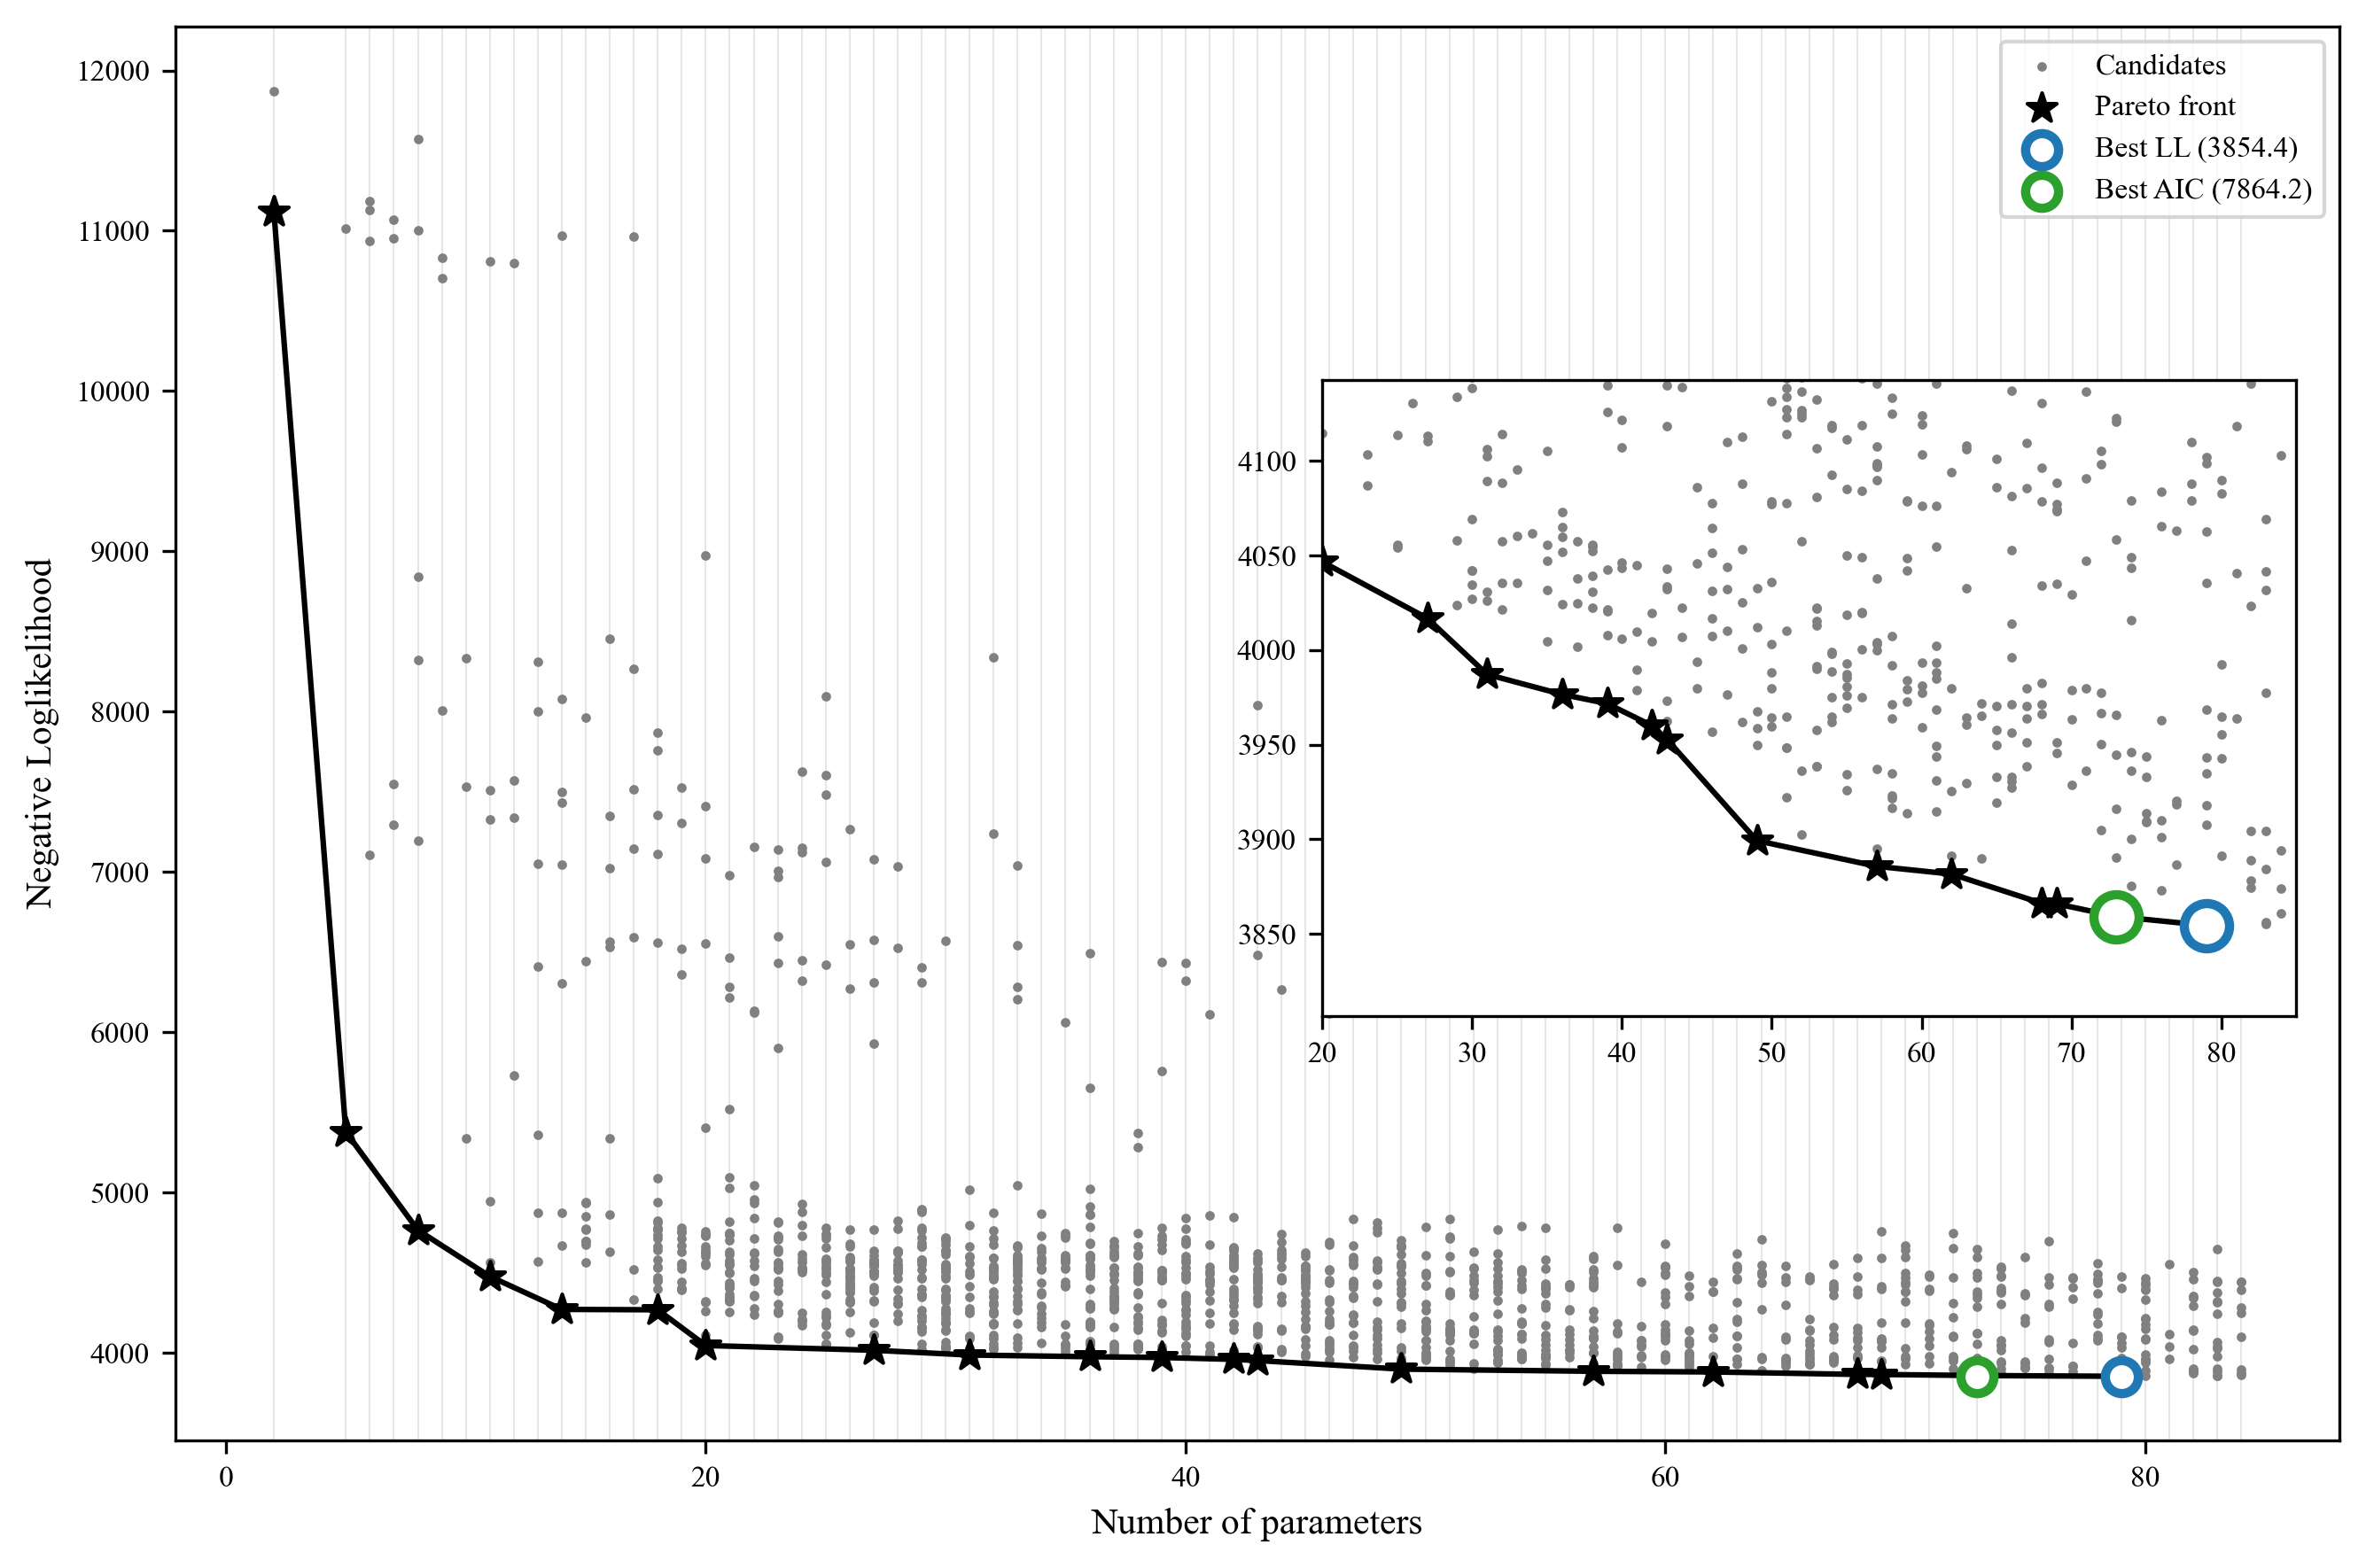

In [ ]:
for _seed in range(104,105):
    base_dir = str(Path.cwd().parent)
    methods = "Delphos"
    seed = f'seed_{_seed}'
    filename = "models_new.csv"
                
    file_path = os.path.join(base_dir, seed, filename)                 
    df = pd.read_csv(file_path, usecols=['successfulEstimation', 'numParams', 'LLout', 'AIC', 'specification'])
    
    # Filter for successfully estimated models and < 85 params
    df = df[df['successfulEstimation'] == True]
    df = df[df['numParams'] < 85]
    
    df['negLLout'] = -1 * df['LLout']
    
    # IMPORTANT: Keep the 'specification' column!
    df = df[['numParams', 'negLLout' , 'AIC', 'specification']].dropna()
    pareto_delphos = df.copy()

    pareto_front_delphos = build_pareto_front(pareto_delphos)
    
    # Find the indices of the minimums
    idx_AIC_delphos = pareto_delphos['AIC'].idxmin() if not pareto_delphos.empty else None
    idx_LL_delphos = pareto_delphos['negLLout'].idxmin() if not pareto_delphos.empty else None
    
    # Print the specifications using .loc
    if idx_AIC_delphos is not None:
        print(f"Best AIC Specification: {pareto_delphos.loc[idx_AIC_delphos]['specification']} (AIC: {pareto_delphos.loc[idx_AIC_delphos]['AIC']})")
        
    if idx_LL_delphos is not None:
        print(f"Best LL Specification: {pareto_delphos.loc[idx_LL_delphos]['specification']} (negLL: {pareto_delphos.loc[idx_LL_delphos]['negLLout']})")

    pareto_plot_zoom(pareto_delphos, pareto_front_delphos, idx_AIC_delphos, idx_LL_delphos, _seed)
